##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
!pip install keras-cv tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 31.0 MB/s eta 0:00:00


Loading YOLOv8 Model...

--- Results for dog.jpeg ---
Detected: dog | Confidence: 99.12%


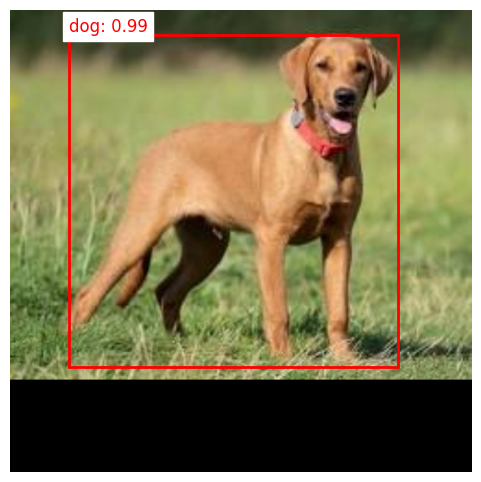


--- Results for car.jpeg ---
Detected: car | Confidence: 97.51%


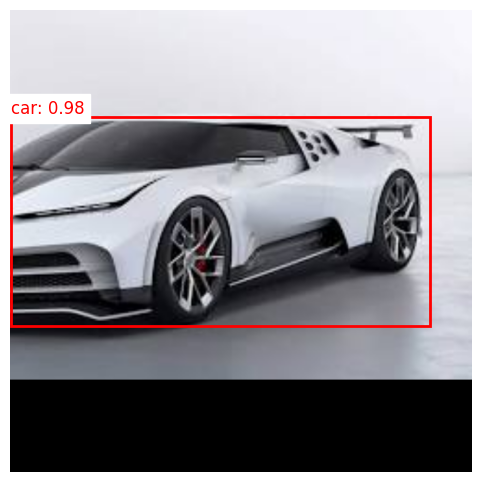


--- Results for aeroplane2.jpg ---
Detected: aeroplane | Confidence: 98.11%


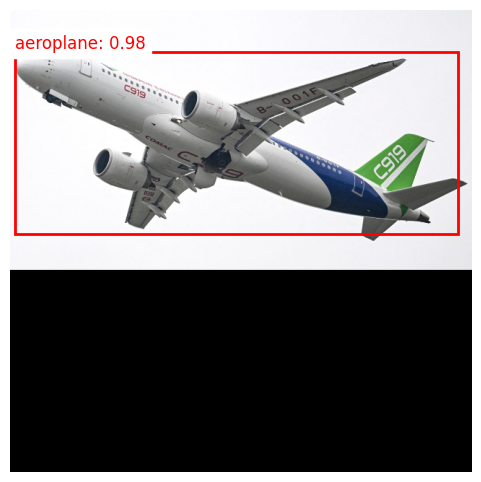


--- Results for person2.jpg ---
Detected: person | Confidence: 98.32%


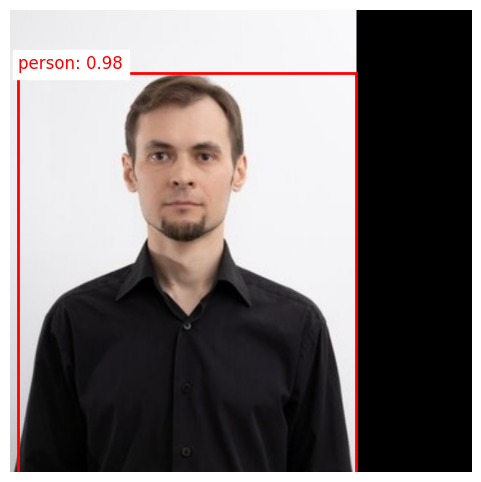


--- Results for chair2.jpg ---
Detected: chair | Confidence: 99.20%


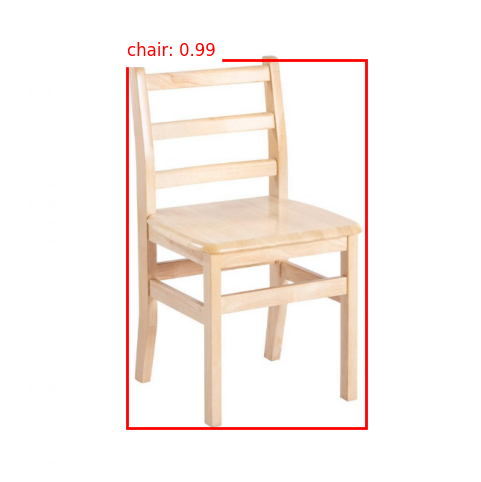

In [11]:
import os
import keras
import keras_cv
import numpy as np
import matplotlib.pyplot as plt

VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
    'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

print("Loading YOLOv8 Model...")
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

image_files_base = ["dog", "car", "aeroplane2", "person2", "chair2"]

for base_name in image_files_base:
    img_path = ""
    if os.path.exists(f"{base_name}.jpg"):
        img_path = f"{base_name}.jpg"
    elif os.path.exists(f"{base_name}.jpeg"):
        img_path = f"{base_name}.jpeg"
    else:
        print(f"Error: Could not find {base_name}.jpg or {base_name}.jpeg in Colab.")
        continue

    try:
        image = keras.utils.load_img(img_path)
        image_array = keras.utils.img_to_array(image)

        image_batch = np.expand_dims(image_array, axis=0)

        resized_dict = inference_resizing({"images": image_batch})
        resized_image_batch = resized_dict["images"]

        predictions = model.predict(resized_image_batch, verbose=0)

        boxes = predictions['boxes'][0]
        classes = predictions['classes'][0]
        confidence = predictions['confidence'][0]

        print(f"\n--- Results for {img_path} ---")

        detected_something = False
        for i in range(len(confidence)):
            if confidence[i] > 0.50:
                detected_something = True
                class_name = VOC_CLASSES[int(classes[i])]
                conf_score = confidence[i] * 100
                print(f"Detected: {class_name} | Confidence: {conf_score:.2f}%")

        if not detected_something:
            print("No objects detected with high confidence.")

        plt.figure(figsize=(6, 6))
        img_to_show = resized_image_batch[0].numpy().astype("uint8")
        plt.imshow(img_to_show)

        for i in range(len(confidence)):
            if confidence[i] > 0.50:
                box = boxes[i]
                # xmin, ymin are directly the top-left coordinates in KerasCV xywh format
                xmin, ymin, w, h = box[0], box[1], box[2], box[3]

                rect = plt.Rectangle((xmin, ymin), w, h, fill=False, edgecolor='red', linewidth=2)
                plt.gca().add_patch(rect)
                plt.text(xmin, ymin - 5, f"{VOC_CLASSES[int(classes[i])]}: {confidence[i]:.2f}",
                         color='red', fontsize=12, backgroundcolor='white')

        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error processing {img_path}. Error: {e}")

### 6. Record My Results

| Image File | Objects Detected Correctly | Confidence Score | Missed or Incorrectly Labeled Objects |
| :--- | :--- | :--- | :--- |
| `dog.jpeg` | Dog | 99.12% | None |
| `car.jpeg` | Car | 97.51% | None |
| `aeroplane2.jpeg` | Aeroplane | 98.11% | None |
| `person2.jpeg` | Person | 98.32% | None |
| `chair2.jpeg` | Chair | 99.20% | None |